# Part B-4 — Robustness to Parametric Uncertainty

**ES4G4 Assignment 1 (Python rebuild)** · The B-1 controller, unchanged, flown on
uncertain plants. Standalone: the design is rebuilt from `quadrotor.py` and `mpc.py`,
so this notebook does not depend on `part_b.ipynb` having been run.

In [4]:
# The B-1 design, rebuilt from the shared modules. Every constant comes from
# quadrotor.py / mpc.py, so nothing here can drift out of step with part_b.ipynb.
import time

import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap, Normalize

from quadrotor import linearised_matrices, PARAMS, TAU_MAX, DEG
from mpc import discretise, weights_for, MPC, simulate, step_metrics, show

np.set_printoptions(precision=4, suppress=True, linewidth=120)

Ts = 2e-3                                  # §2  sample time
ZETA, WN = 1.0, 500.0                      # §6/§7  damping ratio, target bandwidth
plant = discretise(*linearised_matrices(), Ts)
n, m = plant.Bd.shape
ctrl = MPC(plant, *weights_for(WN, plant, ZETA))

# the B-2 scenario, unchanged
ref_b2 = np.zeros(n); ref_b2[0], ref_b2[1] = 10 * DEG, -10 * DEG
x0_b2 = np.zeros(n); x0_b2[0], x0_b2[1] = 5 * DEG, -5 * DEG
ref_b2_of_t = lambda tk: ref_b2 if tk >= 10.0 else np.zeros(n)

print(f"controller rebuilt: wn = {WN:.0f} rad/s, zeta = {ZETA}, Ts = {Ts*1e3:.0f} ms")

controller rebuilt: wn = 500 rad/s, zeta = 1.0, Ts = 2 ms


**Scenario (from the brief).** The inertias $I_{x,y,z}$ and damping coefficients
$d_{x,y,z}$ are approximations and may differ from their Table 1 values by $55\%$ and
$75\%$. Each uncertain plant scales the nominal parameters by six independent factors,

$$f_I \sim \mathcal{U}[0.45,\ 1.55], \qquad f_d \sim \mathcal{U}[0.25,\ 1.75],$$

substitutes them into the *parametric* $(\mathbf{A}, \mathbf{B})$ of A-2 — no uncertain
matrix is written by hand — and discretises with the same exact ZOH of §3. The B-2 scenario
is then re-run on each: same initial condition, same step at $t = 10$ s, same $15$ s.

Fifteen samples are drawn from a seeded generator so the table reproduces. A **sixteenth
run, labelled separately and not one of the fifteen, sits at the deterministic worst
corner** ($f_I = 1.55$, $f_d = 0.25$). Independent draws reach that corner with probability
$0.045$ per axis, so fifteen of them report what the draw happened to contain rather than
what the design tolerates.

**The controller is not redesigned — that is the experiment.** `ctrl` keeps the nominal
$\mathbf{Q}, \mathbf{R}, \mathbf{R}_\Delta, \mathbf{P}$ and, more importantly, the *nominal*
$(\mathbf{A}_d, \mathbf{B}_d)$ inside its prediction model; only the plant handed to
`simulate` changes. The controller optimises the motion of a machine it is not flying, and
the loop is held together by state feedback alone.

**Three predictions, stated before the run.**

1. **Damping uncertainty is irrelevant, despite the larger percentage.** The open-loop pole
   it sets, $-d/I = -0.167$ rad/s, lies a factor of $2\,900$ inside the closed loop's
   $|s| = 483$ rad/s; a $\pm75\%$ swing moves it to $[-0.29, -0.042]$, still three orders of
   magnitude inside the bandwidth. Inertia differs in kind — it enters $\mathbf{B}$ as $1/I$
   and scales control authority directly.
2. **$I_z$ and $d_z$ can have no effect at all.** The linearised plant is block-diagonal by
   axis (A-2) and yaw is neither commanded nor disturbed here, so $\tau_z \equiv 0$ and
   $\psi \equiv 0$ on every sample: only **four** of the six perturbed parameters can move
   any number in the table.
3. **Inertia uncertainty breaks the $5\%$ overshoot specification.** The mechanism is
   one-sided: when the true inertia exceeds the modelled one the controller under-estimates
   the momentum it must arrest, commands too little braking torque, and overshoots; when it
   is lower it over-brakes and simply arrives early. Overshoot should rise monotonically
   with $f_I$ and be indifferent to $f_d$.

In [5]:
# B-4 — the same controller, uncertain plants. Only the plant handed to simulate
# changes: ctrl keeps the nominal weights and the nominal (Ad, Bd) inside its OCP.
KEYS = ("Ix", "Iy", "Iz", "dx", "dy", "dz")
F_I, F_D, N_SAMPLES = 0.55, 0.75, 15

rng = np.random.default_rng(4)                          # seeded: the table reproduces
FAC = np.hstack([rng.uniform(1 - F_I, 1 + F_I, (N_SAMPLES, 3)),
                 rng.uniform(1 - F_D, 1 + F_D, (N_SAMPLES, 3))])
FAC = np.vstack([FAC, [1 + F_I] * 3 + [1 - F_D] * 3])   # worst corner, not a sample
LABELS = [f"sample {i + 1:02d}" for i in range(N_SAMPLES)] + ["worst corner"]

XU, rows = [], {}
t_wall = time.perf_counter()
for i, (lab, fac) in enumerate(zip(LABELS, FAC)):
    p_s = {**PARAMS, **{k: f * PARAMS[k] for k, f in zip(KEYS, fac)}}
    _, Xs, Us, _ = simulate(ctrl, discretise(*linearised_matrices(p_s), Ts),
                            x0_b2, ref_b2_of_t, T_end=15.0)
    mr = step_metrics(Xs, Us, Ts, 10.0, 10 * DEG, axis=0)
    mp = step_metrics(Xs, Us, Ts, 10.0, -10 * DEG, axis=1)
    XU.append((Xs, Us))
    rows[lab] = dict(f_Ix=fac[0], f_Iy=fac[1], f_dx=fac[3], f_dy=fac[4],
                     os_roll=mr["overshoot_pc"], os_pitch=mp["overshoot_pc"],
                     rise_ms=max(mr["rise_ms"], mp["rise_ms"]),
                     settle_ms=max(mr["settle_ms"], mp["settle_ms"]))
    el, left = time.perf_counter() - t_wall, len(LABELS) - 1 - i
    print(f"\r[{'#' * (i + 1)}{'.' * left}] {i + 1}/{len(LABELS)}  {el:3.0f} s elapsed"
          f", ~{el / (i + 1) * left:3.0f} s left  ({lab})   ", end="", flush=True)
print(f"\n\n{len(LABELS)} runs x {len(XU[0][1])} solves in {el:.0f} s wall clock\n")
show(rows, label="run (f = factor)")

# one point per axis-transient: each axis judged against its own two factors
OS = np.array([[rows[l]["os_roll"], rows[l]["os_pitch"]] for l in LABELS])
fI, fd, s = FAC[:, [0, 1]], FAC[:, [3, 4]], slice(None, N_SAMPLES)
r_I = np.corrcoef(fI[s].ravel(), OS[s].ravel())[0, 1]
r_d = np.corrcoef(fd[s].ravel(), OS[s].ravel())[0, 1]
n_breach = (OS[s].max(1) > 5).sum()
Ua = np.array([u for _, u in XU])

print(f"\nFINDING  inertia drives overshoot (r = {r_I:+.2f}); "
      f"damping does not (r = {r_d:+.2f})")
print(f"FINDING  {n_breach} of {N_SAMPLES} samples breach the 5% overshoot spec "
      f"({(OS[s] > 5).sum()} of {2 * N_SAMPLES} axis-transients); "
      f"worst sample {OS[s].max():.2f}%, worst corner {OS[-1, 0]:.2f}%")
print(f"FINDING  every other spec survives: rise <= "
      f"{max(rows[l]['rise_ms'] for l in LABELS):.0f} ms on all runs (spec 1000 ms), "
      f"peak ||tau||_2 = {np.linalg.norm(Ua, axis=2).max():.4f} N.m (limit {TAU_MAX})")
print(f"FINDING  Iz and dz are structurally inert here: max|tau_z| = "
      f"{np.abs(Ua[:, :, 2]).max():.1e} N.m, yaw is never excited")

[################] 16/16  240 s elapsed, ~  0 s left  (worst corner)   

16 runs x 7500 solves in 240 s wall clock

run (f = factor)                  f_Ix          f_Iy          f_dx          f_dy       os_roll      os_pitch       rise_ms     settle_ms
sample 01                        1.487         1.012        0.5061         0.582         6.802        0.1063            10            26
sample 02                       0.5389         1.118         1.576        0.8234             0        0.9912            10            22
sample 03                        1.332         0.642         0.313         1.623         4.227             0            10            24
sample 04                        1.048         1.442          1.48        0.6639        0.5463          6.23            10            26
sample 05                       0.9235         1.318        0.7721         1.709             0         4.396            10            24
sample 06                       0.8567         1.516        0.

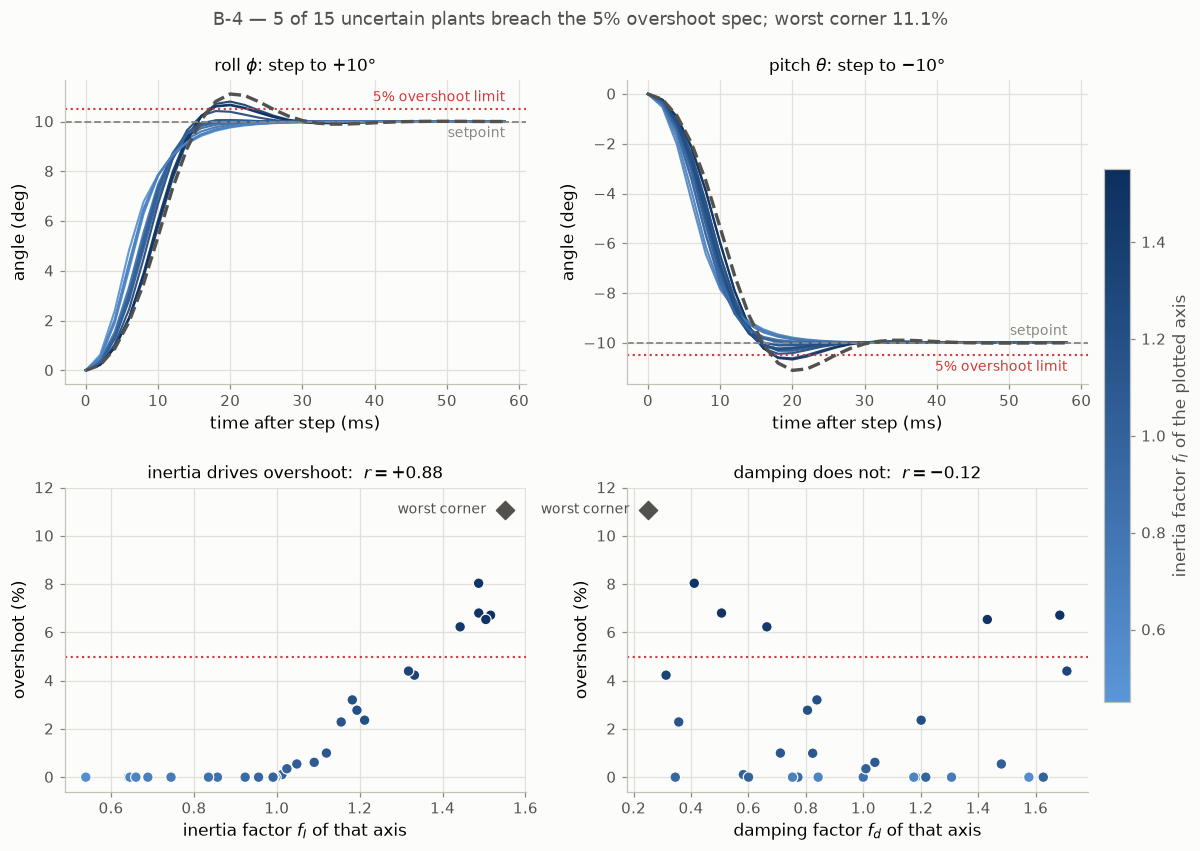

In [6]:
# B-4 figure. Colour carries the inertia factor of the axis being plotted — one
# sequential ramp shared by all four panels. The worst corner is not a sample, so it
# is drawn as ink rather than as a step on the ramp. Panel titles carry the finding.
INK, MUTED, GRID_C, CRIT = "#52514e", "#898781", "#e1e0d9", "#d03b3b"
plt.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 200, "savefig.bbox": "tight",
    "font.size": 11, "axes.titlesize": 11, "axes.labelsize": 11,
    "xtick.labelsize": 9.5, "ytick.labelsize": 9.5,
    "axes.grid": True, "grid.color": GRID_C, "grid.linewidth": 0.8,
    "axes.edgecolor": "#c3c2b7", "axes.spines.top": False, "axes.spines.right": False,
    "xtick.color": MUTED, "ytick.color": MUTED,
    "xtick.labelcolor": INK, "ytick.labelcolor": INK,
    "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
})
RAMP = LinearSegmentedColormap.from_list("inertia", ["#5b96d8", "#0c2f5e"])
NORM = Normalize(1 - F_I, 1 + F_I)
K0, K1 = int(round(10.0 / Ts)), int(round(10.06 / Ts))    # 60 ms after the step
tms = (np.arange(K0, K1) - K0) * Ts * 1e3
CORNER = N_SAMPLES

fig, ax = plt.subplots(2, 2, figsize=(12.5, 8.4),
                       gridspec_kw=dict(hspace=0.34, wspace=0.22))

for col, (axis, tgt, title) in enumerate(
        [(0, 10.0, r"roll $\phi$: step to $+10°$"),
         (1, -10.0, r"pitch $\theta$: step to $-10°$")]):
    a = ax[0, col]
    for i, (Xs, _) in enumerate(XU):
        y = Xs[K0:K1, axis] / DEG
        if i == CORNER:
            a.plot(tms, y, color=INK, lw=2.2, ls="--", zorder=3)
        else:
            a.plot(tms, y, color=RAMP(NORM(FAC[i, axis])), lw=1.4, alpha=0.9)
    a.axhline(tgt, color=MUTED, ls="--", lw=1.2)
    a.axhline(tgt * 1.05, color=CRIT, ls=":", lw=1.4)
    a.annotate("5% overshoot limit", (tms[-1], tgt * 1.05), color=CRIT, fontsize=9,
               ha="right", va="bottom" if tgt > 0 else "top",
               xytext=(0, 3 * np.sign(tgt)), textcoords="offset points")
    a.annotate("setpoint", (tms[-1], tgt), color=MUTED, fontsize=9, ha="right",
               va="top" if tgt > 0 else "bottom", xytext=(0, -3 * np.sign(tgt)),
               textcoords="offset points")
    a.set(xlabel="time after step (ms)", ylabel="angle (deg)", title=title)

dot = dict(s=48, cmap=RAMP, norm=NORM, edgecolor="#fcfcfb", linewidths=0.8, zorder=3)
for col, (xv, xlabel, title) in enumerate(
        [(fI, "inertia factor $f_I$ of that axis",
          f"inertia drives overshoot:  $r = {r_I:+.2f}$"),
         (fd, "damping factor $f_d$ of that axis",
          f"damping does not:  $r = {r_d:+.2f}$")]):
    a = ax[1, col]
    a.scatter(xv[s].ravel(), OS[s].ravel(), c=fI[s].ravel(), **dot)
    a.scatter(xv[CORNER, 0], OS[CORNER, 0], marker="D", s=70, color=INK, zorder=4)
    a.annotate("worst corner", (xv[CORNER, 0], OS[CORNER, 0]), color=INK, fontsize=9,
               ha="right", va="center", xytext=(-12, 0), textcoords="offset points")
    a.axhline(5.0, color=CRIT, ls=":", lw=1.4)
    a.set(xlabel=xlabel, ylabel="overshoot (%)", title=title, ylim=(-0.6, 12.0))

cb = fig.colorbar(plt.cm.ScalarMappable(norm=NORM, cmap=RAMP), ax=ax.ravel().tolist(),
                  location="right", fraction=0.025, pad=0.015)
cb.set_label("inertia factor $f_I$ of the plotted axis", color=INK)
cb.ax.tick_params(color=MUTED, labelcolor=INK)
cb.outline.set_edgecolor("#c3c2b7")
fig.suptitle(f"B-4 — {n_breach} of {N_SAMPLES} uncertain plants breach the 5% overshoot "
             f"spec; worst corner {OS[-1, 0]:.1f}%", color=INK, fontsize=12, y=0.955)
plt.show()

### B-4 results

> **Inertia error drives overshoot; damping error does nothing.** $r = +0.88$ against
> $r = -0.12$ across the thirty axis-transients — and the parameter carrying the *larger*
> nominal uncertainty ($\pm75\%$) is the one that does not matter.
>
> **5 of the 15 samples breach the $5\%$ overshoot specification** on at least one axis.
> Worst sample $8.04\%$; worst corner $11.08\%$, more than double the limit.
>
> **Every other specification survives untouched.** Rise time $10$ ms on all sixteen runs
> against a $1$ s spec, the torque budget honoured exactly, and zero steady-state error.
>
> **Two of the six perturbed parameters are structurally inert.** $I_z$ and $d_z$ cannot
> move any number in this scenario: $\tau_z \equiv \psi \equiv 0$ to the last bit.

**All three predictions hold.**

*Prediction 2 holds exactly.* $\tau_z$ and $\psi$ are zero on all sixteen runs, because the
linearised plant is block-diagonal by axis and yaw is never excited. Worth stating plainly: a
robustness study reporting "six uncertain parameters, all sampled" would be overstating its
own coverage — the effective parameter space here is four-dimensional.

*Prediction 1 holds.* The residual $r = -0.12$ on damping is sampling noise, not physics,
since $f_I$ and $f_d$ are drawn independently. The bottom-right panel makes the point
visually: vertical position tracks the *colour* of each point, not its $x$ position. The loop
bandwidth simply swamps the pole that damping sets.

*Prediction 3 holds, and is the finding.* Overshoot rises monotonically with $f_I$ from
identically zero below nominal. The mechanism is the one predicted: a heavier-than-modelled
airframe carries more momentum into the setpoint than the controller's internal model
expects, so the braking torque it plans is too small and the angle sails past.

**What survives every plant, and why structurally.**

- **The torque budget is honoured exactly** — peak $\|\boldsymbol\tau\|_2 = 0.2500$ N·m. The
  constraint is imposed on $\mathbf{u}$ itself inside the OCP, not on a predicted state, so
  plant error cannot violate it. A gain-based design checks actuator limits after the fact.
- **No steady-state error**, despite gain errors up to $55\%$ and no integral action anywhere
  (§1): the setpoint is an exact fixed point of the *uncertain* $\mathbf{A}_d$ at
  $\mathbf{u} = \mathbf{0}$ too, since the angle rows are pure integrators whatever $I$ and
  $d$ are.
- **Rise time is insensitive** — $10$ ms on every run; settling stretches only from $16$ ms
  to $30$ ms across the whole ensemble.

**The trade this exposes.** Overshoot is the one specification with no margin, and it is the
one §7 traded away. Bandwidth was raised to $\omega_n = 500$ rad/s to meet B-3's $1°$
disturbance budget; that same aggression leaves no room for inertia error, because a faster
loop plans a harder brake and a harder brake is what a heavier plant defeats. At
$\omega_n = 250$ the same corner overshoots only $5.33\%$ (`part_b_extras.ipynb` §10) —
nearly compliant — but B-3 then misses its budget. Both specifications are reached through
the same knob, in opposite directions, and the nominal design cannot satisfy both across the
full uncertainty range.

**What would fix it**, in increasing order of cost: (i) synthesise $\mathbf{P}$ from a DARE
on the *heavy* plant rather than the nominal one — free at run time, and it buys back most of
the margin at some nominal performance; (ii) add an explicit overshoot constraint
$\phi \le 1.05\,\phi_r$ to the OCP, which MPC can express directly and a fixed-gain design
cannot; (iii) min-max or tube MPC over the uncertainty set, the principled answer and
considerably more expensive. Part D's nonlinear MPC targets a different failure — model
*structure* rather than model *parameters* — so it should not be expected to fix this one.